In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    classification_report
)

In [2]:
df = pd.read_csv("../Data/Recommendation_crop_dataset.csv")
df.head()

,CROPS,TYPE_OF_CROP,SOIL,SEASON,SOWN,HARVESTED,WATER_SOURCE,SOIL_PH,SOIL_PH_HIGH,CROPDURATION,...,WATERREQUIRED,WATERREQUIRED_MAX,RELATIVE_HUMIDITY,RELATIVE_HUMIDITY_MAX,N,N_MAX,P,P_MAX,K,K_MAX
0,rice,cereals,Alluvial soil,kharif,Jun,Sep,irrigated,7.6,8.0,116.9,...,2462.3,2500,73.8,80,82.4,100,40.7,60,42.2,60
1,rice,cereals,Loamy soil,kharif,Jul,Oct,rainfed,6.2,8.0,117.9,...,1237.5,2500,60.9,80,90.5,100,51.3,60,46.2,60
2,rice,cereals,Clay soil,kharif,Jun,Sep,irrigated,6.7,8.0,117.7,...,1075.1,2500,67.5,80,86.2,100,50.7,60,44.4,60
3,rice,cereals,Alluvial soil,kharif,Jul,Oct,rainfed,6.1,8.0,149.8,...,1549.9,2500,73.6,80,91.3,100,51.3,60,44.5,60
4,rice,cereals,Loamy soil,kharif,Jun,Sep,irrigated,8.0,8.0,131.7,...,1306.4,2500,60.3,80,81.3,100,48.6,60,51.0,60


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CROPS                  57000 non-null  object 
 1   TYPE_OF_CROP           57000 non-null  object 
 2   SOIL                   57000 non-null  object 
 3   SEASON                 57000 non-null  object 
 4   SOWN                   57000 non-null  object 
 5   HARVESTED              57000 non-null  object 
 6   WATER_SOURCE           57000 non-null  object 
 7   SOIL_PH                57000 non-null  float64
 8   SOIL_PH_HIGH           57000 non-null  float64
 9   CROPDURATION           57000 non-null  float64
 10  CROPDURATION_MAX       57000 non-null  int64  
 11  TEMP                   57000 non-null  float64
 12  MAX_TEMP               57000 non-null  int64  
 13  WATERREQUIRED          57000 non-null  float64
 14  WATERREQUIRED_MAX      57000 non-null  int64  
 15  RE

In [4]:
df.drop(["SOIL_PH_HIGH","CROPDURATION_MAX","MAX_TEMP","WATERREQUIRED_MAX","RELATIVE_HUMIDITY_MAX","N_MAX","P_MAX","K_MAX","SOWN","HARVESTED"],axis = 1,inplace=True)

In [5]:
df

,CROPS,TYPE_OF_CROP,SOIL,SEASON,WATER_SOURCE,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
0,rice,cereals,Alluvial soil,kharif,irrigated,7.6,116.9,26.9,2462.3,73.8,82.4,40.7,42.2
1,rice,cereals,Loamy soil,kharif,rainfed,6.2,117.9,35.8,1237.5,60.9,90.5,51.3,46.2
2,rice,cereals,Clay soil,kharif,irrigated,6.7,117.7,34.9,1075.1,67.5,86.2,50.7,44.4
3,rice,cereals,Alluvial soil,kharif,rainfed,6.1,149.8,28.3,1549.9,73.6,91.3,51.3,44.5
4,rice,cereals,Loamy soil,kharif,irrigated,8.0,131.7,26.3,1306.4,60.3,81.3,48.6,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56995,small onion,bulbvegetables,sandy Loamy soil,Zaid,rainfed,6.2,86.6,21.7,701.9,66.0,73.8,44.5,57.9
56996,small onion,bulbvegetables,sandy Loamy soil,Zaid,irrigated,6.4,70.3,20.5,653.5,66.2,72.4,50.5,55.1
56997,small onion,bulbvegetables,sandy Loamy soil,Zaid,rainfed,6.4,86.3,18.6,743.3,65.6,70.5,59.8,58.5
56998,small onion,bulbvegetables,sandy Loamy soil,Zaid,irrigated,6.2,89.1,23.1,736.8,74.2,66.8,40.2,55.3


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.drop(["TYPE_OF_CROP"],axis=1,inplace=True)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CROPS              57000 non-null  object 
 1   SOIL               57000 non-null  object 
 2   SEASON             57000 non-null  object 
 3   WATER_SOURCE       57000 non-null  object 
 4   SOIL_PH            57000 non-null  float64
 5   CROPDURATION       57000 non-null  float64
 6   TEMP               57000 non-null  float64
 7   WATERREQUIRED      57000 non-null  float64
 8   RELATIVE_HUMIDITY  57000 non-null  float64
 9   N                  57000 non-null  float64
 10  P                  57000 non-null  float64
 11  K                  57000 non-null  float64
dtypes: float64(8), object(4)
memory usage: 5.2+ MB


In [9]:
df.describe()

,SOIL_PH,CROPDURATION,TEMP,WATERREQUIRED,RELATIVE_HUMIDITY,N,P,K
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,6.624367,109.347488,24.757740,887.262882,71.197588,81.284277,48.197891,56.605086
std,0.649972,52.931444,5.862506,356.326523,23.158554,33.786202,17.160902,27.438288
min,5.000000,21.000000,5.000000,330.000000,15.000000,20.000000,20.000000,20.000000
25%,6.200000,75.900000,21.100000,604.600000,64.400000,56.600000,34.975000,34.900000
50%,6.600000,99.900000,24.800000,929.500000,78.200000,80.500000,47.700000,50.500000
75%,7.000000,120.500000,28.000000,1070.100000,85.300000,100.800000,58.000000,75.400000
max,9.000000,330.000000,47.000000,2499.800000,100.000000,199.900000,100.000000,149.900000


In [10]:
df.nunique()

CROPS                   57
SOIL                    34
SEASON                   3
WATER_SOURCE             2
SOIL_PH                 41
CROPDURATION          2269
TEMP                   418
WATERREQUIRED        12749
RELATIVE_HUMIDITY      552
N                     1770
P                      801
K                     1293
dtype: int64

<Axes: >

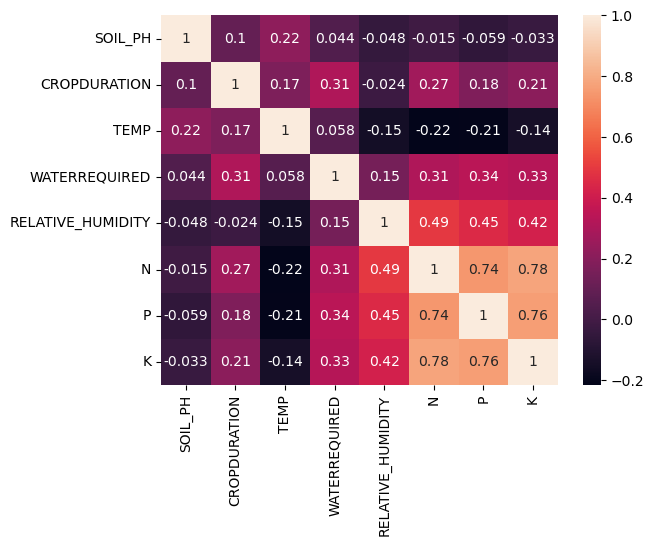

In [11]:
correlation = df.corr(numeric_only = True)
sns.heatmap(correlation,xticklabels=correlation.columns ,yticklabels=correlation.columns,annot = True)

In [12]:
X = df.drop("CROPS", axis=1)
y = df["CROPS"]

In [13]:
le = LabelEncoder()

y_encoded = le.fit_transform(df["CROPS"])

mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'Cabbage': 0, 'Pearl millet': 1, 'annual moringa': 2, 'ash gourd': 3, 'beetroot': 4, 'bengalgram': 5, 'bhendi': 6, 'bitter gourd': 7, 'blackgram': 8, 'bottle gourd': 9, 'brinjal': 10, 'capsicum': 11, 'carrot': 12, 'castor': 13, 'cauliflower': 14, 'chillies': 15, 'chowchow': 16, 'cluster bean': 17, 'cotton': 18, 'cowpea': 19, 'cucumber': 20, 'elephant foot yam': 21, 'french bean': 22, 'gingely': 23, 'greengram': 24, 'groundnut': 25, 'horsegram': 26, 'jute': 27, 'kudiraivali': 28, 'maize': 29, 'muskmelon': 30, 'onion': 31, 'panivaragu': 32, 'peas': 33, 'pumpkin': 34, 'radish': 35, 'ragi': 36, 'redgram': 37, 'ribbed gourd': 38, 'rice': 39, 'samai': 40, 'small onion': 41, 'snake gourd': 42, 'sorghum': 43, 'soyabean': 44, 'sugarbeet': 45, 'sugarcane': 46, 'sunflower': 47, 'sweet potato': 48, 'tapoica': 49, 'thinai': 50, 'tinda': 51, 'tomato': 52, 'varagu': 53, 'vegetable cowpea': 54, 'watermelon': 55, 'wheat': 56}


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Features
    y_encoded,         # Encoded target
    test_size=0.2,     # 20% testing data
    random_state=42,   # For reproducibility
    stratify=y_encoded # Important for multi-class (57 crops)
)

In [15]:
numerical_cols = ["SOIL_PH","CROPDURATION","TEMP","WATERREQUIRED",
                  "RELATIVE_HUMIDITY","N","P","K"]

categorical_cols = ["SOIL","SEASON","WATER_SOURCE"]
for col in categorical_cols:
    X[col] = X[col].str.lower().str.strip()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [19]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
    max_iter=10000,
    solver='saga'
))
])

log_model.fit(X_train, y_train)

log_acc = log_model.score(X_test, y_test)
print("Logistic Accuracy:", log_acc)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)

# ---------------- Metrics ----------------
log_acc = accuracy_score(y_test, y_pred)
log_precision = precision_score(y_test, y_pred, average='weighted')
log_recall = recall_score(y_test, y_pred, average='weighted')
log_f1 = f1_score(y_test, y_pred, average='weighted')
logloss = log_loss(y_test, y_prob)

print("Accuracy :", log_acc)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)
print("Log Loss :", logloss)

Logistic Accuracy: 0.9942982456140351
Accuracy : 0.9942982456140351
Precision: 0.9943882431038432
Recall   : 0.9942982456140351
F1 Score : 0.9943110276980299
Log Loss : 0.037728422631077


In [17]:
print("Train:", log_model.score(X_train, y_train))
print("Test:", log_model.score(X_test, y_test))

Train: 0.9946929824561404
Test: 0.9942982456140351


In [21]:
y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       0.99      0.97      0.98       200
           2       1.00      1.00      1.00       200
           3       0.99      0.96      0.98       200
           4       1.00      1.00      1.00       200
           5       1.00      1.00      1.00       200
           6       1.00      0.99      1.00       200
           7       1.00      1.00      1.00       200
           8       1.00      1.00      1.00       200
           9       0.93      0.98      0.95       200
          10       1.00      0.99      0.99       200
          11       1.00      1.00      1.00       200
          12       1.00      1.00      1.00       200
          13       1.00      1.00      1.00       200
          14       1.00      1.00      1.00       200
          15       0.98      0.97      0.98       200
          16       1.00      1.00      1.00       200
          17       0.99    

In [22]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"  # keeps numerical as-is
)


In [23]:
dt_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_acc = dt_model.score(X_test, y_test)
print("Decision Tree Accuracy:", dt_acc)

y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)

dt_acc = accuracy_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred, average='weighted')
dt_recall = recall_score(y_test, y_pred, average='weighted')
dt_f1 = f1_score(y_test, y_pred, average='weighted')
dt_logloss = log_loss(y_test, y_prob)

# ---------------- Print Results ----------------
print("Decision Tree Performance:")
print("Accuracy :", round(dt_acc, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("Log Loss :", round(dt_logloss, 4))

Decision Tree Accuracy: 0.998859649122807
Decision Tree Performance:
Accuracy : 0.9989
Precision: 0.9989
Recall   : 0.9989
F1 Score : 0.9989
Log Loss : 0.0411


In [33]:
rf_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

rf_acc = rf_model.score(X_test, y_test)
print("Random Forest Accuracy:", rf_acc)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)

# ---------------- Metrics ----------------
rf_acc = accuracy_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred, average='weighted')
rf_recall = recall_score(y_test, y_pred, average='weighted')
rf_f1 = f1_score(y_test, y_pred, average='weighted')
rf_logloss = log_loss(y_test, y_prob)

# ---------------- Print Results ----------------
print("Random Forest Performance:")
print("Accuracy :", round(rf_acc, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("Log Loss :", round(rf_logloss, 4))

Random Forest Accuracy: 0.9999122807017544
Random Forest Performance:
Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9999
F1 Score : 0.9999
Log Loss : 0.0132


In [25]:
import pickle
pickle.dump(rf_model, open("../Models/rf_model.pkl", "wb"))
pickle.dump(dt_model, open("../Models/dt_model.pkl", "wb"))
pickle.dump(log_model, open("../Models/log_model.pkl", "wb"))

In [26]:
allowed_values = {
    "soil": X["SOIL"].unique().tolist(),
    "season": X["SEASON"].unique().tolist(),
    "water_source": X["WATER_SOURCE"].unique().tolist()
}

with open("../Data/categories.pkl", "wb") as f:
    pickle.dump(allowed_values, f)

In [27]:
with open("../Data/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [28]:
from sklearn.metrics import log_loss

# Get predicted probabilities (VERY IMPORTANT)
y_prob =log_model.predict_proba(X_test)

# Calculate log loss
loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)

Log Loss: 0.037728422631077


In [29]:
# Get trained RF model from pipeline
rf = rf_model.named_steps['classifier']

# Get feature importance
importances = rf.feature_importances_

# Get feature names AFTER preprocessing
preprocessor = rf_model.named_steps['preprocessor']

# This gets correct transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

print("\nFeature Importance:")
print(feature_importance)



Feature Importance:
                                         Feature  Importance
40                       remainder__CROPDURATION    0.161929
42                      remainder__WATERREQUIRED    0.118564
43                  remainder__RELATIVE_HUMIDITY    0.112977
44                                  remainder__N    0.073208
46                                  remainder__K    0.066033
39                            remainder__SOIL_PH    0.063154
41                               remainder__TEMP    0.061138
45                                  remainder__P    0.038312
24                    cat__SOIL_sandy Loamy soil    0.035364
4                           cat__SOIL_Loamy soil    0.023040
36                              cat__SEASON_rabi    0.022151
35                            cat__SEASON_kharif    0.018507
34                              cat__SEASON_Zaid    0.017366
29             cat__SOIL_well-drained loamy soil    0.016828
6                           cat__SOIL_Sandy soil    0.016304
30 

In [30]:
import numpy as np
import pandas as pd

clf = log_model.named_steps["classifier"]
feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()

# Average absolute coefficients across all classes
importance = np.mean(np.abs(clf.coef_), axis=0)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                                         Feature  Importance
1                              num__CROPDURATION    2.832611
3                             num__WATERREQUIRED    2.093618
4                         num__RELATIVE_HUMIDITY    2.051755
5                                         num__N    1.662967
7                                         num__K    1.657188
32                    cat__SOIL_sandy Loamy soil    1.457934
43                            cat__SEASON_kharif    1.327378
44                              cat__SEASON_rabi    1.266094
2                                      num__TEMP    1.221000
0                                   num__SOIL_PH    1.139727
12                          cat__SOIL_Loamy soil    1.127993
42                              cat__SEASON_Zaid    1.122137
6                                         num__P    0.964529
46                     cat__WATER_SOURCE_rainfed    0.890697
45                   cat__WATER_SOURCE_irrigated    0.763061
38 

In [31]:
feature_means = X[numerical_cols].mean()

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

# ---------------- Build Model ----------------
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),   # use scaled/encoded preprocessor
    ("classifier", KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2,
    n_jobs=-1
    
    ))
])

# ---------------- Train Model ----------------
knn_model.fit(X_train, y_train)

# ---------------- Predictions ----------------
y_pred = knn_model.predict(X_test)
y_prob = knn_model.predict_proba(X_test)

# ---------------- Metrics ----------------
knn_acc = accuracy_score(y_test, y_pred)
knn_precision = precision_score(y_test, y_pred, average='weighted')
knn_recall = recall_score(y_test, y_pred, average='weighted')
knn_f1 = f1_score(y_test, y_pred, average='weighted')
knn_logloss = log_loss(y_test, y_prob)

# ---------------- Print Results ----------------
print("KNN Performance:")
print("Accuracy :", round(knn_acc, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1 Score :", round(knn_f1, 4))
print("Log Loss :", round(knn_logloss, 4))

KNN Performance:
Accuracy : 0.9277
Precision: 0.9287
Recall   : 0.9277
F1 Score : 0.9258
Log Loss : 0.3632
